# Generalized Label Exploration

This notebook explores whether training on `activity_general` is a better fit than training on the original `activity` labels.

It focuses on four questions:
1. How much class imbalance improves after grouping.
2. Which labels are still rare after grouping.
3. How broadly each label appears across homes.
4. Whether each generalized bucket is fairly coherent or still semantically mixed.


In [2]:
from pathlib import Path
from typing import Final

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

pl.Config.set_tbl_rows(100)
pl.Config.set_tbl_cols(20)
sns.set_theme(style="whitegrid")


In [3]:
PROJECT_ROOT: Path = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR: Final[Path] = PROJECT_ROOT / "data" / "raw"
SAMPLE_FRACTION: float | None = 0.20
RANDOM_SEED: Final[int] = 42

data_files = sorted(DATA_DIR.glob("csh*/csh*.ann.features.csv"))
print(f"Found {len(data_files)} feature files")
print(f"Sampling fraction: {SAMPLE_FRACTION}")


Found 30 feature files
Sampling fraction: 0.2


In [4]:
general_map: dict[str, str] = {
    "Bathe": "Hygiene",
    "Personal_Hygiene": "Hygiene",
    "Groom": "Hygiene",
    "Toilet": "Hygiene",
    "Bed_Toilet_Transition": "Hygiene",
    "Dress": "Hygiene",
    "Cook": "Meal_Prep",
    "Cook_Breakfast": "Meal_Prep",
    "Cook_Lunch": "Meal_Prep",
    "Cook_Dinner": "Meal_Prep",
    "Wash_Dishes": "Meal_Cleanup",
    "Wash_Breakfast_Dishes": "Meal_Cleanup",
    "Wash_Lunch_Dishes": "Meal_Cleanup",
    "Wash_Dinner_Dishes": "Meal_Cleanup",
    "Eat": "Eating",
    "Drink": "Eating",
    "Eat_Breakfast": "Eating",
    "Eat_Lunch": "Eating",
    "Eat_Dinner": "Eating",
    "Sleep": "Sleep_Rest",
    "Go_To_Sleep": "Sleep_Rest",
    "Wake_Up": "Sleep_Rest",
    "Nap": "Sleep_Rest",
    "Sleep_Out_Of_Bed": "Sleep_Rest",
    "Work": "Work_Study",
    "Work_On_Computer": "Work_Study",
    "Work_At_Desk": "Work_Study",
    "Work_At_Table": "Work_Study",
    "Exercise": "Exercise",
    "Read": "Leisure",
    "Phone": "Leisure",
    "Relax": "Leisure",
    "Watch_TV": "Leisure",
    "Entertain_Guests": "Leisure",
    "Morning_Meds": "Medication",
    "Evening_Meds": "Medication",
    "Take_Medicine": "Medication",
    "Enter_Home": "Home_Transition",
    "Leave_Home": "Home_Transition",
    "Step_Out": "Home_Transition",
    "Laundry": "Household",
}


In [5]:
frames: list[pl.DataFrame] = []

for idx, file_path in enumerate(data_files):
    home_id = file_path.parent.name
    df_home = (
        pl.scan_csv(str(file_path))
        .with_columns(pl.lit(home_id).alias("home_id"))
        .with_columns(pl.col("activity").str.replace(r"^r[12]\\.", "").alias("activity"))
        .filter(pl.col("activity") != "Other_Activity")
        .with_columns(pl.col("activity").replace(general_map).alias("activity_general"))
        .collect()
    )

    if SAMPLE_FRACTION is not None:
        df_home = df_home.sample(fraction=SAMPLE_FRACTION, seed=RANDOM_SEED + idx, shuffle=True)

    frames.append(df_home)

df = pl.concat(frames, how="vertical")
print(df.shape)
df.select("home_id", "activity", "activity_general").head()


(1837304, 39)


home_id,activity,activity_general
str,str,str
"""csh101""","""Sleep_Out_Of_Bed""","""Sleep_Rest"""
"""csh101""","""Watch_TV""","""Leisure"""
"""csh101""","""Watch_TV""","""Leisure"""
"""csh101""","""Watch_TV""","""Leisure"""
"""csh101""","""Bathe""","""Hygiene"""


## High-Level Comparison

This compares the specific label space against the generalized one. The goal is to see whether grouping meaningfully reduces imbalance and data sparsity.


In [6]:
specific_counts = df.group_by("activity").len().sort("len", descending=True)
general_counts = df.group_by("activity_general").len().sort("len", descending=True)

def summarize_counts(count_df: pl.DataFrame, label_space: str) -> dict[str, float | str]:
    counts = count_df.get_column("len").to_numpy()
    return {
        "label_space": label_space,
        "n_classes": int(len(counts)),
        "total_rows": int(counts.sum()),
        "min_count": int(counts.min()),
        "p25_count": float(np.percentile(counts, 25)),
        "median_count": float(np.median(counts)),
        "mean_count": float(np.mean(counts)),
        "max_count": int(counts.max()),
        "max_to_min_ratio": float(counts.max() / counts.min()),
    }

comparison = pl.DataFrame([
    summarize_counts(specific_counts, "specific"),
    summarize_counts(general_counts, "generalized"),
])

comparison


label_space,n_classes,total_rows,min_count,p25_count,median_count,mean_count,max_count,max_to_min_ratio
str,i64,i64,i64,f64,f64,f64,i64,f64
"""specific""",41,1837304,19,11287.0,25037.0,44812.292683,254285,13383.421053
"""generalized""",11,1837304,19,39153.0,127576.0,167027.636364,487159,25639.947368


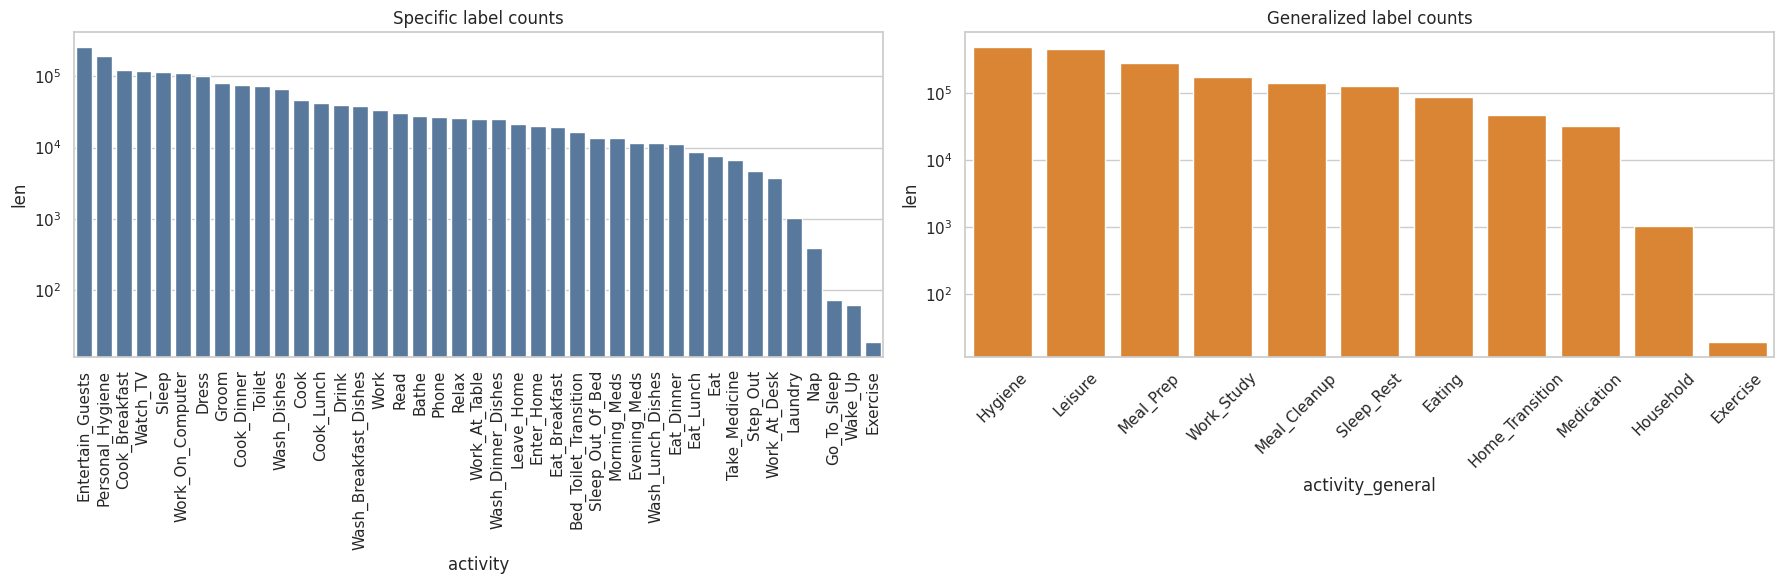

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

specific_pd = specific_counts.to_pandas()
general_pd = general_counts.to_pandas()

sns.barplot(data=specific_pd, x="activity", y="len", ax=axes[0], color="#4C78A8")
axes[0].set_title("Specific label counts")
axes[0].set_yscale("log")
axes[0].tick_params(axis="x", rotation=90)

sns.barplot(data=general_pd, x="activity_general", y="len", ax=axes[1], color="#F58518")
axes[1].set_title("Generalized label counts")
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()


## Rare Labels

If the specific label space is dominated by rare classes, generalized labels may be a better training target.


In [8]:
rarity_thresholds = [100, 500, 1000, 5000]

rarity_summary = pl.DataFrame({
    "threshold": rarity_thresholds,
    "specific_labels_below": [specific_counts.filter(pl.col("len") < t).height for t in rarity_thresholds],
    "generalized_labels_below": [general_counts.filter(pl.col("len") < t).height for t in rarity_thresholds],
})

rarity_summary


threshold,specific_labels_below,generalized_labels_below
i64,i64,i64
100,3,1
500,4,1
1000,4,1
5000,7,2


In [9]:
specific_counts.sort("len").head(15)


activity,len
str,u32
"""Exercise""",19
"""Wake_Up""",62
"""Go_To_Sleep""",74
"""Nap""",397
"""Laundry""",1035
"""Work_At_Desk""",3765
"""Step_Out""",4685
"""Take_Medicine""",6747
"""Eat""",7641


In [10]:
general_counts.sort("len").head(15)


activity_general,len
str,u32
"""Exercise""",19
"""Household""",1035
"""Medication""",32023
"""Home_Transition""",46283
"""Eating""",87125
"""Sleep_Rest""",127576
"""Meal_Cleanup""",141277
"""Work_Study""",172149
"""Meal_Prep""",286052


## Home Coverage

A label that appears in only a few homes is much harder to generalize across homes.


In [11]:
specific_home_coverage = (
    df.group_by("activity")
    .agg([
        pl.col("home_id").n_unique().alias("n_homes"),
        pl.len().alias("n_rows"),
    ])
    .sort(["n_homes", "n_rows"], descending=[False, False])
)

general_home_coverage = (
    df.group_by("activity_general")
    .agg([
        pl.col("home_id").n_unique().alias("n_homes"),
        pl.len().alias("n_rows"),
    ])
    .sort(["n_homes", "n_rows"], descending=[False, False])
)

print("Specific labels with weakest home coverage")
display(specific_home_coverage.head(15))

print("Generalized labels with weakest home coverage")
display(general_home_coverage)


Specific labels with weakest home coverage


activity,n_homes,n_rows
str,u32,u32
"""Exercise""",1,19
"""Wake_Up""",1,62
"""Go_To_Sleep""",1,74
"""Nap""",1,397
"""Laundry""",1,1035
"""Work_At_Desk""",3,3765
"""Take_Medicine""",13,6747
"""Work""",13,33499
"""Work_On_Computer""",20,109848


Generalized labels with weakest home coverage


activity_general,n_homes,n_rows
str,u32,u32
"""Exercise""",1,19
"""Household""",1,1035
"""Medication""",27,32023
"""Home_Transition""",30,46283
"""Eating""",30,87125
"""Sleep_Rest""",30,127576
"""Meal_Cleanup""",30,141277
"""Work_Study""",30,172149
"""Meal_Prep""",30,286052


## Bucket Coherence

This shows how each generalized label is composed. If a generalized bucket is dominated by one child label, grouping is mostly a support boost. If it is very mixed, grouping trades away more specificity.


In [12]:
bucket_children = (
    df.group_by(["activity_general", "activity"])
    .len()
    .sort(["activity_general", "len"], descending=[False, True])
)

bucket_profile = (
    bucket_children.group_by("activity_general")
    .agg([
        pl.len().alias("n_specific_children"),
        pl.sum("len").alias("total_rows"),
        pl.max("len").alias("largest_child_rows"),
        pl.col("activity").first().alias("largest_child"),
    ])
    .with_columns((pl.col("largest_child_rows") / pl.col("total_rows")).alias("largest_child_share"))
    .sort("total_rows", descending=True)
)

bucket_profile


activity_general,n_specific_children,total_rows,largest_child_rows,largest_child,largest_child_share
str,u32,u32,u32,str,f64
"""Hygiene""",6,487159,190496,"""Personal_Hygiene""",0.391035
"""Leisure""",5,456606,254285,"""Entertain_Guests""",0.556902
"""Meal_Prep""",4,286052,122965,"""Cook_Breakfast""",0.429869
"""Work_Study""",4,172149,109848,"""Work_On_Computer""",0.638098
"""Meal_Cleanup""",4,141277,66282,"""Wash_Dishes""",0.469163
"""Sleep_Rest""",5,127576,113317,"""Sleep""",0.888231
"""Eating""",5,87125,39960,"""Drink""",0.458651
"""Home_Transition""",3,46283,21287,"""Leave_Home""",0.459931
"""Medication""",3,32023,13606,"""Morning_Meds""",0.424882


In [13]:
bucket_children


activity_general,activity,len
str,str,u32
"""Eating""","""Drink""",39960
"""Eating""","""Eat_Breakfast""",19662
"""Eating""","""Eat_Dinner""",11287
"""Eating""","""Eat_Lunch""",8575
"""Eating""","""Eat""",7641
"""Exercise""","""Exercise""",19
"""Home_Transition""","""Leave_Home""",21287
"""Home_Transition""","""Enter_Home""",20311
"""Home_Transition""","""Step_Out""",4685


## Decision Helpers

Use this section to make the training-target decision.

Generalized labels are more attractive when:
- many specific labels are rare,
- many specific labels appear in only a few homes,
- generalized buckets are reasonably coherent,
- and your goal is strong macro-level recognition rather than fine-grained sub-activities.

Specific labels remain attractive when:
- you need the exact sub-activity,
- the rare classes are still important enough to preserve,
- or grouping creates buckets that are too semantically mixed.


In [14]:
decision_table = pd.DataFrame({
    "question": [
        "How many classes?",
        "Smallest class count",
        "Median class count",
        "Worst imbalance ratio (max/min)",
        "Labels under 1000 rows",
    ],
    "specific": [
        specific_counts.height,
        int(specific_counts["len"].min()),
        float(np.median(specific_counts["len"].to_numpy())),
        float(specific_counts["len"].max() / specific_counts["len"].min()),
        int(specific_counts.filter(pl.col("len") < 1000).height),
    ],
    "generalized": [
        general_counts.height,
        int(general_counts["len"].min()),
        float(np.median(general_counts["len"].to_numpy())),
        float(general_counts["len"].max() / general_counts["len"].min()),
        int(general_counts.filter(pl.col("len") < 1000).height),
    ],
})

decision_table


,question,specific,generalized
0,How many classes?,41.000000,11.000000
1,Smallest class count,19.000000,19.000000
2,Median class count,25037.000000,127576.000000
3,Worst imbalance ratio (max/min),13383.421053,25639.947368
4,Labels under 1000 rows,4.000000,1.000000


## Quick Baseline Comparison

This section runs a lightweight XGBoost baseline on the same sampled data for both targets:
- `activity`
- `activity_general`

It is intentionally cheap and uses row-level stratified CV, so it is useful for a quick target comparison, not for a final generalization claim.


In [15]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

feature_columns = [
    col for col in df.columns
    if col not in {"activity", "activity_general", "home_id"} and df[col].dtype.is_numeric()
]
X = df.select(feature_columns).to_numpy().astype(np.float32)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
scoring = {
    "f1_macro": make_scorer(f1_score, average="macro", zero_division=0),
    "f1_weighted": make_scorer(f1_score, average="weighted", zero_division=0),
    "accuracy": "accuracy",
}

baseline_results: list[dict[str, float | str | int]] = []

for target_column in ["activity", "activity_general"]:
    encoder = LabelEncoder()
    y = encoder.fit_transform(df[target_column].to_numpy())

    model = xgb.XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        n_estimators=250,
        learning_rate=0.08,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_SEED,
        n_jobs=1,
        verbosity=0,
    )

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
    )

    baseline_results.append({
        "target": target_column,
        "n_classes": int(len(encoder.classes_)),
        "cv_f1_macro_mean": float(scores["test_f1_macro"].mean()),
        "cv_f1_macro_std": float(scores["test_f1_macro"].std()),
        "cv_f1_weighted_mean": float(scores["test_f1_weighted"].mean()),
        "cv_accuracy_mean": float(scores["test_accuracy"].mean()),
    })

baseline_comparison = pd.DataFrame(baseline_results).sort_values("cv_f1_macro_mean", ascending=False)
baseline_comparison


,target,n_classes,cv_f1_macro_mean,cv_f1_macro_std,cv_f1_weighted_mean,cv_accuracy_mean
1,activity_general,11,0.719799,0.015601,0.783793,0.792076
0,activity,41,0.656567,0.002145,0.698975,0.708340
